# 17 - Perbandingan Lengkap: Semua Model, Skenario, dan Konfigurasi

**Tujuan:** Notebook ini melakukan perbandingan komprehensif **seluruh eksperimen** yang telah dilakukan:
- **From Scratch vs Transfer Learning**
- **7-Class vs 4-Class**
- **Unimodal vs Multimodal (Fusion)**
- **Semua skenario penanganan imbalance (B1, B2, B3)**

**Konfigurasi Eksperimen:**

| Aspek | Variasi |
| --- | --- |
| Jumlah Kelas | 7-class (original), 4-class (merged) |
| CNN Variant | From Scratch, Transfer Learning (VGG16) |
| Model Type | CNN, FCNN, Late Fusion, Intermediate Fusion |
| Skenario Imbalance | B1 (baseline), B2 (class weights), B3 (weights + augmentasi) |

**Metric Utama:** Macro F1 Score (karena dataset sangat imbalanced)

## 1. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project root
PROJECT_ROOT = Path("..").resolve()

# Plot style
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

SCENARIO_SHORT = ["B1", "B2", "B3"]

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/bs000716/MOTHER-TANK/TRAIN


## 2. Load ALL Results

In [2]:
# ============================================================
# Define ALL JSON result file paths
# ============================================================

result_files = {
    # --- 7-class From Scratch ---
    ("7-class", "From Scratch", "CNN"): PROJECT_ROOT / "models" / "cnn" / "cnn_results.json",
    ("7-class", "From Scratch", "FCNN"): PROJECT_ROOT / "models" / "fcnn" / "fcnn_results.json",
    ("7-class", "From Scratch", "Late Fusion"): PROJECT_ROOT / "models" / "late_fusion" / "late_fusion_results.json",
    ("7-class", "From Scratch", "Intermediate Fusion"): PROJECT_ROOT / "models" / "intermediate_fusion" / "intermediate_fusion_results.json",

    # --- 7-class Transfer Learning ---
    ("7-class", "Transfer Learning", "CNN"): PROJECT_ROOT / "models" / "cnn_transfer" / "cnn_transfer_results.json",
    ("7-class", "Transfer Learning", "FCNN"): PROJECT_ROOT / "models" / "fcnn" / "fcnn_results.json",  # FCNN same
    ("7-class", "Transfer Learning", "Late Fusion"): PROJECT_ROOT / "models" / "late_fusion_transfer" / "late_fusion_transfer_results.json",
    ("7-class", "Transfer Learning", "Intermediate Fusion"): PROJECT_ROOT / "models" / "intermediate_fusion_transfer" / "intermediate_fusion_transfer_results.json",

    # --- 4-class From Scratch ---
    ("4-class", "From Scratch", "CNN"): PROJECT_ROOT / "models" / "4class" / "cnn" / "cnn_4class_results.json",
    ("4-class", "From Scratch", "FCNN"): PROJECT_ROOT / "models" / "4class" / "fcnn" / "fcnn_4class_results.json",
    ("4-class", "From Scratch", "Late Fusion"): PROJECT_ROOT / "models" / "4class" / "late_fusion" / "late_fusion_4class_results.json",
    ("4-class", "From Scratch", "Intermediate Fusion"): PROJECT_ROOT / "models" / "4class" / "intermediate_fusion" / "intermediate_fusion_4class_results.json",

    # --- 4-class Transfer Learning ---
    ("4-class", "Transfer Learning", "CNN"): PROJECT_ROOT / "models" / "4class" / "cnn_transfer" / "cnn_transfer_4class_results.json",
    ("4-class", "Transfer Learning", "FCNN"): PROJECT_ROOT / "models" / "4class" / "fcnn" / "fcnn_4class_results.json",  # FCNN same
    ("4-class", "Transfer Learning", "Late Fusion"): PROJECT_ROOT / "models" / "4class" / "late_fusion_transfer" / "late_fusion_transfer_4class_results.json",
    ("4-class", "Transfer Learning", "Intermediate Fusion"): PROJECT_ROOT / "models" / "4class" / "intermediate_fusion_transfer" / "intermediate_fusion_transfer_4class_results.json",
}

# Load all available results
all_raw = {}
for key, path in result_files.items():
    if path.exists():
        with open(path, "r") as f:
            all_raw[key] = json.load(f)
        print(f"[OK]   {key[0]:8s} | {key[1]:20s} | {key[2]:22s} <- {path.name}")
    else:
        print(f"[MISS] {key[0]:8s} | {key[1]:20s} | {key[2]:22s} <- {path.name} (not found)")

print(f"\nLoaded: {len(all_raw)} / {len(result_files)} result files")

[OK]   7-class  | From Scratch         | CNN                    <- cnn_results.json
[OK]   7-class  | From Scratch         | FCNN                   <- fcnn_results.json
[OK]   7-class  | From Scratch         | Late Fusion            <- late_fusion_results.json
[OK]   7-class  | From Scratch         | Intermediate Fusion    <- intermediate_fusion_results.json
[OK]   7-class  | Transfer Learning    | CNN                    <- cnn_transfer_results.json
[OK]   7-class  | Transfer Learning    | FCNN                   <- fcnn_results.json
[OK]   7-class  | Transfer Learning    | Late Fusion            <- late_fusion_transfer_results.json
[OK]   7-class  | Transfer Learning    | Intermediate Fusion    <- intermediate_fusion_transfer_results.json
[OK]   4-class  | From Scratch         | CNN                    <- cnn_4class_results.json
[OK]   4-class  | From Scratch         | FCNN                   <- fcnn_4class_results.json
[OK]   4-class  | From Scratch         | Late Fusion            <- l

## 3. Helper Functions

In [3]:
def extract_best(results_dict):
    """Get best scenario from results dict."""
    best_f1 = 0
    best_name = ""
    for name, metrics in results_dict.items():
        f1 = metrics.get("macro_f1", metrics.get("test_macro_f1", 0))
        if f1 > best_f1:
            best_f1 = f1
            best_name = name
    return best_name, best_f1


def extract_metrics(metrics):
    """Safely extract accuracy, macro_f1, weighted_f1 from different JSON formats."""
    accuracy = metrics.get("accuracy", metrics.get("test_accuracy", 0))
    macro_f1 = metrics.get("macro_f1", metrics.get("test_macro_f1", 0))
    weighted_f1 = metrics.get("weighted_f1", metrics.get("test_weighted_f1", 0))
    return accuracy, macro_f1, weighted_f1


def scenario_short(name):
    """Convert scenario name to short label."""
    if "B1" in name:
        return "B1"
    elif "B2" in name:
        return "B2"
    elif "B3" in name:
        return "B3"
    return name


print("Helper functions defined.")

Helper functions defined.


## 4. Master Comparison Table

Tabel ini berisi **semua kombinasi** yang telah diuji, diurutkan berdasarkan Macro F1 tertinggi.

In [4]:
# Build master dataframe from all loaded results
rows = []

for (class_config, cnn_variant, model_type), results in all_raw.items():
    for scenario_name, metrics in results.items():
        accuracy, macro_f1, weighted_f1 = extract_metrics(metrics)
        rows.append({
            "Class Config": class_config,
            "Model Type": model_type,
            "CNN Variant": cnn_variant,
            "Best Scenario": scenario_short(scenario_name),
            "Accuracy": accuracy,
            "Macro F1": macro_f1,
            "Weighted F1": weighted_f1,
        })

df_master = pd.DataFrame(rows)
df_master = df_master.sort_values("Macro F1", ascending=False).reset_index(drop=True)
df_master.index = df_master.index + 1
df_master.index.name = "Rank"

print(f"Total combinations: {len(df_master)} rows")
print()

styled = df_master.style \
    .format({"Accuracy": "{:.4f}", "Macro F1": "{:.4f}", "Weighted F1": "{:.4f}"}) \
    .background_gradient(subset=["Macro F1"], cmap="YlGn") \
    .set_caption("Master Comparison Table - Semua Eksperimen")
styled

Total combinations: 48 rows



,Class Config,Model Type,CNN Variant,Best Scenario,Accuracy,Macro F1,Weighted F1
Rank,,,,,,,
1,4-class,Late Fusion,Transfer Learning,B2,0.9390,0.4423,0.9459
2,4-class,CNN,Transfer Learning,B2,0.9155,0.4071,0.9322
3,4-class,FCNN,Transfer Learning,B3,0.9438,0.3941,0.9431
4,4-class,FCNN,From Scratch,B3,0.9438,0.3941,0.9431
5,4-class,Late Fusion,Transfer Learning,B3,0.9438,0.3941,0.9431
6,4-class,Late Fusion,From Scratch,B3,0.9457,0.3850,0.9427
7,4-class,Intermediate Fusion,Transfer Learning,B3,0.9438,0.3758,0.9455
8,4-class,Intermediate Fusion,Transfer Learning,B2,0.9366,0.3535,0.9409
9,4-class,FCNN,From Scratch,B1,0.9583,0.3301,0.9430


## 5. From Scratch vs Transfer Learning

Perbandingan side-by-side untuk model yang memiliki versi From Scratch dan Transfer Learning (CNN, Late Fusion, Intermediate Fusion). FCNN tidak menggunakan transfer learning karena hanya berbasis landmarks.

In [5]:
# Compare From Scratch vs Transfer Learning for CNN-based models
# Only models that have both variants: CNN, Late Fusion, Intermediate Fusion
tl_models = ["CNN", "Late Fusion", "Intermediate Fusion"]

for class_config in ["7-class", "4-class"]:
    print("=" * 75)
    print(f"  FROM SCRATCH vs TRANSFER LEARNING - {class_config}")
    print("=" * 75)
    
    comparison_rows = []
    for model_type in tl_models:
        key_scratch = (class_config, "From Scratch", model_type)
        key_tl = (class_config, "Transfer Learning", model_type)
        
        if key_scratch in all_raw:
            best_name_s, best_f1_s = extract_best(all_raw[key_scratch])
        else:
            best_name_s, best_f1_s = "N/A", 0.0
        
        if key_tl in all_raw:
            best_name_tl, best_f1_tl = extract_best(all_raw[key_tl])
        else:
            best_name_tl, best_f1_tl = "N/A", 0.0
        
        if best_f1_s > 0:
            improvement = ((best_f1_tl - best_f1_s) / best_f1_s) * 100
        else:
            improvement = 0.0
        
        comparison_rows.append({
            "Model": model_type,
            "Scratch Best (Scenario)": best_name_s,
            "Scratch Macro F1": best_f1_s,
            "TL Best (Scenario)": best_name_tl,
            "TL Macro F1": best_f1_tl,
            "Improvement %": improvement,
        })
    
    df_tl_cmp = pd.DataFrame(comparison_rows)
    styled_tl = df_tl_cmp.style \
        .format({"Scratch Macro F1": "{:.4f}", "TL Macro F1": "{:.4f}", "Improvement %": "{:+.2f}%"}) \
        .applymap(lambda x: "color: green; font-weight: bold" if isinstance(x, (int, float)) and x > 0 else 
                  ("color: red; font-weight: bold" if isinstance(x, (int, float)) and x < 0 else ""),
                  subset=["Improvement %"])
    display(styled_tl)
    print()

  FROM SCRATCH vs TRANSFER LEARNING - 7-class


/tmp/ipykernel_109698/283798243.py:40: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_tl = df_tl_cmp.style \


,Model,Scratch Best (Scenario),Scratch Macro F1,TL Best (Scenario),TL Macro F1,Improvement %
0,CNN,B2 Class Weights,0.1335,B2 Class Weights,0.1772,+32.73%
1,Late Fusion,B1,0.2298,B1,0.2343,+1.94%
2,Intermediate Fusion,B2 Class Weights,0.1399,B1 Baseline,0.2322,+65.99%



  FROM SCRATCH vs TRANSFER LEARNING - 4-class


/tmp/ipykernel_109698/283798243.py:40: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_tl = df_tl_cmp.style \


,Model,Scratch Best (Scenario),Scratch Macro F1,TL Best (Scenario),TL Macro F1,Improvement %
0,CNN,B2 Class Weights,0.2960,B2 Class Weights,0.4071,+37.55%
1,Late Fusion,B3,0.3850,B2,0.4423,+14.87%
2,Intermediate Fusion,B2 Class Weights,0.2581,B3 Weights+Aug,0.3758,+45.59%


## 6. 7-Class vs 4-Class

Perbandingan performa antara konfigurasi 7-class (original) dan 4-class (merged: happy+surprised -> positive, sad+fearful+disgusted -> negative).

In [6]:
# Compare 7-class vs 4-class for each model type + CNN variant
for cnn_variant in ["From Scratch", "Transfer Learning"]:
    print("=" * 75)
    print(f"  7-CLASS vs 4-CLASS - CNN Variant: {cnn_variant}")
    print("=" * 75)
    
    comparison_rows = []
    for model_type in ["CNN", "FCNN", "Late Fusion", "Intermediate Fusion"]:
        key_7 = ("7-class", cnn_variant, model_type)
        key_4 = ("4-class", cnn_variant, model_type)
        
        if key_7 in all_raw:
            best_name_7, best_f1_7 = extract_best(all_raw[key_7])
        else:
            best_name_7, best_f1_7 = "N/A", 0.0
        
        if key_4 in all_raw:
            best_name_4, best_f1_4 = extract_best(all_raw[key_4])
        else:
            best_name_4, best_f1_4 = "N/A", 0.0
        
        if best_f1_7 > 0:
            improvement = ((best_f1_4 - best_f1_7) / best_f1_7) * 100
        else:
            improvement = 0.0
        
        comparison_rows.append({
            "Model": model_type,
            "7-class Best (Scenario)": best_name_7,
            "7-class Macro F1": best_f1_7,
            "4-class Best (Scenario)": best_name_4,
            "4-class Macro F1": best_f1_4,
            "Improvement %": improvement,
        })
    
    df_class_cmp = pd.DataFrame(comparison_rows)
    styled_class = df_class_cmp.style \
        .format({"7-class Macro F1": "{:.4f}", "4-class Macro F1": "{:.4f}", "Improvement %": "{:+.2f}%"}) \
        .applymap(lambda x: "color: green; font-weight: bold" if isinstance(x, (int, float)) and x > 0 else 
                  ("color: red; font-weight: bold" if isinstance(x, (int, float)) and x < 0 else ""),
                  subset=["Improvement %"])
    display(styled_class)
    print()

  7-CLASS vs 4-CLASS - CNN Variant: From Scratch


/tmp/ipykernel_109698/2693849395.py:37: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_class = df_class_cmp.style \


,Model,7-class Best (Scenario),7-class Macro F1,4-class Best (Scenario),4-class Macro F1,Improvement %
0,CNN,B2 Class Weights,0.1335,B2 Class Weights,0.2960,+121.65%
1,FCNN,B1 Baseline,0.2343,B3 Weights+Aug,0.3941,+68.23%
2,Late Fusion,B1,0.2298,B3,0.3850,+67.53%
3,Intermediate Fusion,B2 Class Weights,0.1399,B2 Class Weights,0.2581,+84.55%



  7-CLASS vs 4-CLASS - CNN Variant: Transfer Learning


/tmp/ipykernel_109698/2693849395.py:37: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_class = df_class_cmp.style \


,Model,7-class Best (Scenario),7-class Macro F1,4-class Best (Scenario),4-class Macro F1,Improvement %
0,CNN,B2 Class Weights,0.1772,B2 Class Weights,0.4071,+129.70%
1,FCNN,B1 Baseline,0.2343,B3 Weights+Aug,0.3941,+68.23%
2,Late Fusion,B1,0.2343,B2,0.4423,+88.77%
3,Intermediate Fusion,B1 Baseline,0.2322,B3 Weights+Aug,0.3758,+61.86%


## 7. Overall Top 5

Lima kombinasi terbaik dari seluruh eksperimen berdasarkan Macro F1.

In [7]:
# Get best scenario per (class_config, cnn_variant, model_type)
best_rows = []
for (class_config, cnn_variant, model_type), results in all_raw.items():
    best_name, best_f1 = extract_best(results)
    # Get full metrics for the best scenario
    best_metrics = results[best_name]
    accuracy, macro_f1, weighted_f1 = extract_metrics(best_metrics)
    
    best_rows.append({
        "Class Config": class_config,
        "CNN Variant": cnn_variant,
        "Model Type": model_type,
        "Best Scenario": scenario_short(best_name),
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
    })

df_best = pd.DataFrame(best_rows)
df_best = df_best.sort_values("Macro F1", ascending=False).reset_index(drop=True)
df_best.index = df_best.index + 1
df_best.index.name = "Rank"

print("=" * 75)
print("  OVERALL TOP 5 - Best Macro F1 per Model Configuration")
print("=" * 75)
print()

top5 = df_best.head(5)
styled_top5 = top5.style \
    .format({"Accuracy": "{:.4f}", "Macro F1": "{:.4f}", "Weighted F1": "{:.4f}"}) \
    .background_gradient(subset=["Macro F1"], cmap="YlGn") \
    .set_caption("Top 5 Kombinasi Terbaik")
display(styled_top5)

# Print summary
best_overall = df_best.iloc[0]
print(f"\nKOMBINASI TERBAIK SECARA KESELURUHAN:")
print(f"  Class Config : {best_overall['Class Config']}")
print(f"  CNN Variant  : {best_overall['CNN Variant']}")
print(f"  Model Type   : {best_overall['Model Type']}")
print(f"  Scenario     : {best_overall['Best Scenario']}")
print(f"  Accuracy     : {best_overall['Accuracy']:.4f}")
print(f"  Macro F1     : {best_overall['Macro F1']:.4f}")
print(f"  Weighted F1  : {best_overall['Weighted F1']:.4f}")

  OVERALL TOP 5 - Best Macro F1 per Model Configuration



,Class Config,CNN Variant,Model Type,Best Scenario,Accuracy,Macro F1,Weighted F1
Rank,,,,,,,
1,4-class,Transfer Learning,Late Fusion,B2,0.9390,0.4423,0.9459
2,4-class,Transfer Learning,CNN,B2,0.9155,0.4071,0.9322
3,4-class,Transfer Learning,FCNN,B3,0.9438,0.3941,0.9431
4,4-class,From Scratch,FCNN,B3,0.9438,0.3941,0.9431
5,4-class,From Scratch,Late Fusion,B3,0.9457,0.3850,0.9427



KOMBINASI TERBAIK SECARA KESELURUHAN:
  Class Config : 4-class
  CNN Variant  : Transfer Learning
  Model Type   : Late Fusion
  Scenario     : B2
  Accuracy     : 0.9390
  Macro F1     : 0.4423
  Weighted F1  : 0.9459


## 8. Visualisasi: Grouped Bar Chart - Semua Model

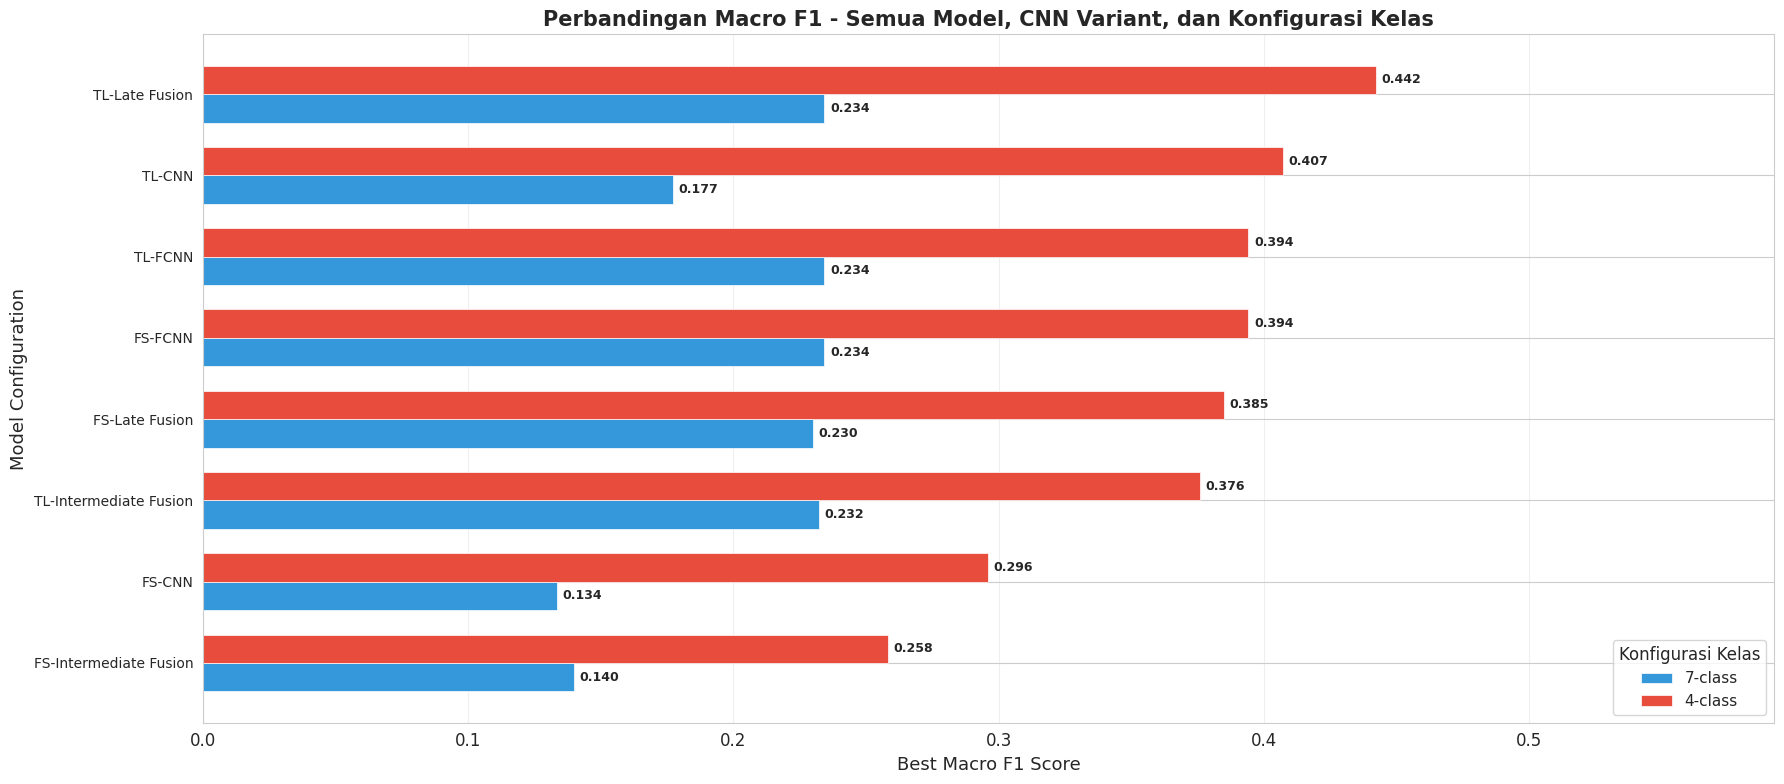

Saved: models/final_comparison_bar.png


In [8]:
# Large grouped bar chart: best Macro F1 per model, grouped by class config
# Create a label combining CNN variant + model type
df_best_plot = df_best.copy()
df_best_plot["Label"] = df_best_plot["CNN Variant"].str[:2] + "-" + df_best_plot["Model Type"]
# FS = From Scratch, TL = Transfer Learning
df_best_plot["Label"] = df_best_plot["Label"].str.replace("Fr-", "FS-").str.replace("Tr-", "TL-")

fig, ax = plt.subplots(figsize=(18, 8))

# Pivot: rows = Label, columns = Class Config
# First, take the best per (Label, Class Config) in case of duplicates
df_pivot_data = df_best_plot.groupby(["Label", "Class Config"])["Macro F1"].max().reset_index()
pivot = df_pivot_data.pivot(index="Label", columns="Class Config", values="Macro F1")

# Sort by max across columns
pivot["max"] = pivot.max(axis=1)
pivot = pivot.sort_values("max", ascending=True).drop(columns="max")

# Ensure column order
col_order = [c for c in ["7-class", "4-class"] if c in pivot.columns]
pivot = pivot[col_order]

x = np.arange(len(pivot.index))
width = 0.35
colors = {"7-class": "#3498db", "4-class": "#e74c3c"}

for i, class_config in enumerate(col_order):
    values = pivot[class_config].fillna(0)
    bars = ax.barh(x + i * width, values, width,
                   label=class_config, color=colors[class_config],
                   edgecolor="white", linewidth=0.5)
    # Add value labels
    for bar in bars:
        w = bar.get_width()
        if w > 0:
            ax.annotate(f"{w:.3f}",
                        xy=(w, bar.get_y() + bar.get_height() / 2),
                        xytext=(4, 0), textcoords="offset points",
                        ha="left", va="center", fontsize=9, fontweight="bold")

ax.set_ylabel("Model Configuration", fontsize=13)
ax.set_xlabel("Best Macro F1 Score", fontsize=13)
ax.set_title("Perbandingan Macro F1 - Semua Model, CNN Variant, dan Konfigurasi Kelas",
             fontsize=15, fontweight="bold")
ax.set_yticks(x + width / 2)
ax.set_yticklabels(pivot.index, fontsize=10)
ax.legend(title="Konfigurasi Kelas", fontsize=11, loc="lower right")
ax.set_xlim(0, min(1.0, pivot.max().max() + 0.15))
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models" / "final_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: models/final_comparison_bar.png")

## 9. Visualisasi: Heatmap Macro F1 - Semua Kombinasi

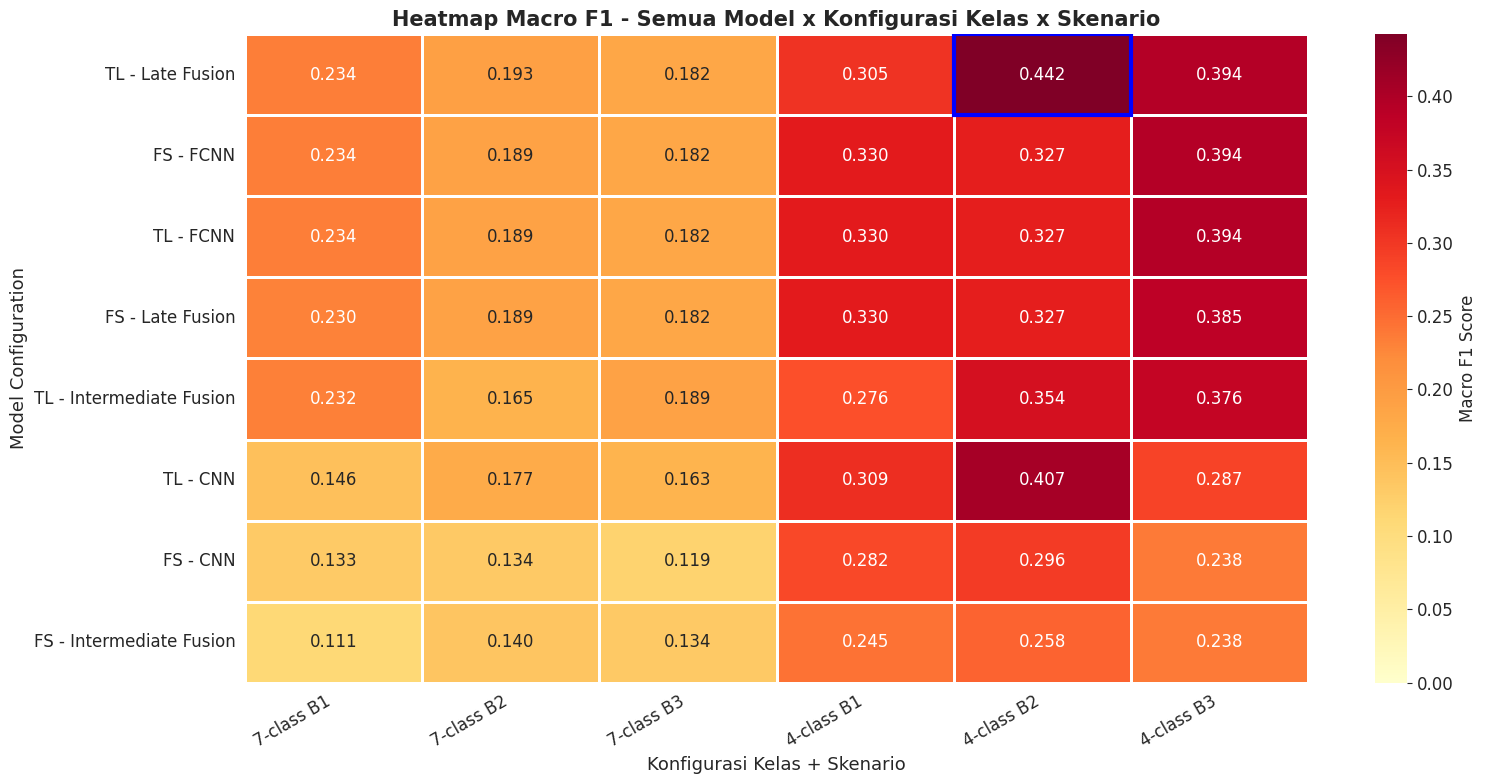

Saved: models/final_comparison_heatmap.png


In [9]:
# Heatmap: rows = model config (CNN Variant + Model Type), columns = Class Config + Scenario
df_heatmap = df_master.copy()
df_heatmap["Row Label"] = df_heatmap["CNN Variant"].str.replace("From Scratch", "FS").str.replace("Transfer Learning", "TL") + " - " + df_heatmap["Model Type"]
df_heatmap["Col Label"] = df_heatmap["Class Config"] + " " + df_heatmap["Best Scenario"]

# Pivot for heatmap
pivot_heat = df_heatmap.pivot_table(index="Row Label", columns="Col Label", values="Macro F1", aggfunc="max")

# Reorder columns logically
col_order_heat = []
for cls in ["7-class", "4-class"]:
    for sc in ["B1", "B2", "B3"]:
        label = f"{cls} {sc}"
        if label in pivot_heat.columns:
            col_order_heat.append(label)
pivot_heat = pivot_heat[[c for c in col_order_heat if c in pivot_heat.columns]]

# Sort rows by mean Macro F1
pivot_heat["mean"] = pivot_heat.mean(axis=1)
pivot_heat = pivot_heat.sort_values("mean", ascending=False).drop(columns="mean")

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    pivot_heat,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=2,
    linecolor="white",
    cbar_kws={"label": "Macro F1 Score"},
    ax=ax,
    vmin=0,
    mask=pivot_heat.isna(),
)

# Highlight overall best cell
max_val = pivot_heat.max().max()
for i in range(len(pivot_heat.index)):
    for j in range(len(pivot_heat.columns)):
        val = pivot_heat.iloc[i, j]
        if pd.notna(val) and val == max_val:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="blue", linewidth=3))

ax.set_title("Heatmap Macro F1 - Semua Model x Konfigurasi Kelas x Skenario",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Konfigurasi Kelas + Skenario", fontsize=13)
ax.set_ylabel("Model Configuration", fontsize=13)
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "models" / "final_comparison_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: models/final_comparison_heatmap.png")

## 10. Kesimpulan

### Temuan Utama

Berdasarkan perbandingan komprehensif seluruh eksperimen:

#### 1. Model + Konfigurasi Terbaik Secara Keseluruhan
- **Model:** _(diisi setelah semua eksperimen selesai)_
- **CNN Variant:** _From Scratch / Transfer Learning_
- **Class Config:** _7-class / 4-class_
- **Skenario:** _B1 / B2 / B3_
- **Macro F1:** _..._

#### 2. Pengaruh Transfer Learning
- Apakah transfer learning (VGG16) meningkatkan performa CNN dari scratch? ...
- Apakah perbaikan konsisten di semua model fusion? ...
- Berapa rata-rata peningkatan Macro F1? ...

#### 3. Pengaruh Class Merging (7-class vs 4-class)
- Apakah mengurangi jumlah kelas meningkatkan Macro F1? ...
- Apakah peningkatan signifikan untuk semua model? ...
- Trade-off: informasi emosi yang hilang vs peningkatan performa ...

#### 4. FCNN vs CNN
- Perbandingan unimodal: apakah facial landmarks (FCNN) lebih baik dari pixel-based (CNN)? ...
- Modalitas mana yang lebih informatif untuk emotion recognition? ...

#### 5. Efektivitas Fusion
- Apakah model multimodal (Late/Intermediate Fusion) lebih baik dari unimodal? ...
- Tipe fusi mana yang lebih efektif: Late Fusion vs Intermediate Fusion? ...
- Apakah fusion memberikan peningkatan konsisten di semua konfigurasi? ...

### Catatan Metodologi
- Semua evaluasi dilakukan pada **test set** yang sama per konfigurasi kelas
- Metric utama: **Macro F1** (memberikan bobot sama pada setiap kelas, penting untuk dataset imbalanced)
- Weighted F1 dan Accuracy digunakan sebagai metric pendukung
- 3 Skenario Imbalance: B1 (baseline), B2 (class weights), B3 (class weights + augmentasi)

## 11. Save Final Comparison

In [10]:
import os

# Build final comparison JSON
final_output = {
    "experiment": "Multimodal Emotion Recognition - Final Comprehensive Comparison",
    "configurations": {
        "class_configs": ["7-class", "4-class"],
        "cnn_variants": ["From Scratch", "Transfer Learning"],
        "model_types": ["CNN", "FCNN", "Late Fusion", "Intermediate Fusion"],
        "scenarios": ["B1", "B2", "B3"],
    },
    "total_combinations_loaded": len(df_master),
    "best_overall": {
        "class_config": str(best_overall["Class Config"]),
        "cnn_variant": str(best_overall["CNN Variant"]),
        "model_type": str(best_overall["Model Type"]),
        "scenario": str(best_overall["Best Scenario"]),
        "accuracy": float(best_overall["Accuracy"]),
        "macro_f1": float(best_overall["Macro F1"]),
        "weighted_f1": float(best_overall["Weighted F1"]),
    },
    "top5": [],
    "all_results": [],
}

# Add top 5
for _, row in df_best.head(5).iterrows():
    final_output["top5"].append({
        "class_config": str(row["Class Config"]),
        "cnn_variant": str(row["CNN Variant"]),
        "model_type": str(row["Model Type"]),
        "scenario": str(row["Best Scenario"]),
        "accuracy": float(row["Accuracy"]),
        "macro_f1": float(row["Macro F1"]),
        "weighted_f1": float(row["Weighted F1"]),
    })

# Add all results
for _, row in df_master.iterrows():
    final_output["all_results"].append({
        "class_config": str(row["Class Config"]),
        "model_type": str(row["Model Type"]),
        "cnn_variant": str(row["CNN Variant"]),
        "scenario": str(row["Best Scenario"]),
        "accuracy": float(row["Accuracy"]),
        "macro_f1": float(row["Macro F1"]),
        "weighted_f1": float(row["Weighted F1"]),
    })

# Save
output_path = PROJECT_ROOT / "models" / "final_comparison.json"
os.makedirs(output_path.parent, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(final_output, f, indent=2, ensure_ascii=False)

print(f"Final comparison saved to: {output_path}")
print(f"Total combinations: {final_output['total_combinations_loaded']}")
print()
print("Best overall:")
for k, v in final_output["best_overall"].items():
    print(f"  {k:15s}: {v}")

Final comparison saved to: /home/bs000716/MOTHER-TANK/TRAIN/models/final_comparison.json
Total combinations: 48

Best overall:
  class_config   : 4-class
  cnn_variant    : Transfer Learning
  model_type     : Late Fusion
  scenario       : B2
  accuracy       : 0.9390096618357487
  macro_f1       : 0.442258727641423
  weighted_f1    : 0.9459263498354891
